In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Import the csv file
df=pd.read_csv('uber.csv')
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [3]:
#Check the shape of the dataset
df.shape

(200000, 9)

In [4]:
#Check the data types of the columns
df.dtypes

Unnamed: 0             int64
key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

In [5]:
#Undertand the dataset for EDA
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [6]:
#Identify Missing Values
#Function to create a dataframe to display null_count and null_percentage for each column
def null_values(data):
    nv=df.isnull().sum()
    nv=nv[nv>0]
    nv_df=pd.DataFrame({'Features':nv.index,'Null_Values':nv.values,'Null_Percent':(nv.values/len(data))*100})
    return nv_df
nv_df=null_values(df)
nv_df

,Features,Null_Values,Null_Percent
0,dropoff_longitude,1,0.0005
1,dropoff_latitude,1,0.0005


In [7]:
#Identify duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
#Handle Null Values
df=df.dropna()
nv_df=null_values(df)
nv_df.head()

,Features,Null_Values,Null_Percent


In [9]:
#Handle Outliers for longitudes and Latitudes
df = df[(df['pickup_latitude'].between(40, 42)) & 
        (df['pickup_longitude'].between(-75, -72)) &
        (df['dropoff_latitude'].between(40, 42)) & 
        (df['dropoff_longitude'].between(-75, -72))]
print(df.shape)

(195806, 9)


In [10]:
#Feature Engineering
#Using Haversine Formula to calculate Distance
def haversine_distance(lat1,lon1,lat2,lon2):
    #Convert degrees to radians
    lat1,lon1,lat2,lon2=map(np.radians,[lat1,lon1,lat2,lon2])

    #Haversine Formula
    lat = lat2 - lat1
    lon = lon2 - lon1
    hf = np.sin(lat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(lon/2)**2
    c = 2 * np.arcsin(np.sqrt(hf))

    #Radius of the Earth in km
    r = 6371

    return c * r

#Applying Formula to df
df['distance_km']=haversine_distance(df['pickup_latitude'],df['pickup_longitude'],df['dropoff_latitude'],df['dropoff_longitude'])
df['distance_km'].head()

0    1.683323
1    2.457590
2    5.036377
3    1.661683
4    4.475450
Name: distance_km, dtype: float64

In [11]:
#Converting pickup_datetime to datetime data type
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'])
#Creating hour column
df['hour']=df['pickup_datetime'].dt.hour
df[['pickup_datetime','hour']].head()

,pickup_datetime,hour
0,2015-05-07 19:52:06+00:00,19
1,2009-07-17 20:04:56+00:00,20
2,2009-08-24 21:45:00+00:00,21
3,2009-06-26 08:22:21+00:00,8
4,2014-08-28 17:47:00+00:00,17


In [12]:
#Create time_label column 
df['time_label']=pd.cut(df['hour'],bins=[0,4,11,16,20,24],labels=['Night','Morning','Afternoon','Evening','Night2'])
df['time_label']=df['time_label'].replace('Night2','Night')
df['time_label'].head()

C:\Users\yeshw\AppData\Local\Temp\ipykernel_26108\1432542351.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['time_label']=df['time_label'].replace('Night2','Night')


0    Evening
1    Evening
2      Night
3    Morning
4    Evening
Name: time_label, dtype: category
Categories (4, object): ['Night' < 'Morning' < 'Afternoon' < 'Evening']

In [13]:
#Create distance_label column
df['distance_label']=pd.cut(df['distance_km'],bins=[0,2,8,df['distance_km'].max()],labels=['short','medium','long'])
df['distance_label'].head()

0     short
1    medium
2    medium
3     short
4    medium
Name: distance_label, dtype: category
Categories (3, object): ['short' < 'medium' < 'long']

In [14]:
#Find Outliers
def find_outliers(df,col):
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    outliers=df[(df[col]<lower) | (df[col]>upper)]
    return outliers

In [15]:
num_cols=['fare_amount', 'passenger_count', 'distance_km']
total_outliers=0
for col in num_cols:
    outliers=find_outliers(df,col)
    print(f'Total Outliers for {col} : {len(outliers)}')
    total_outliers+=len(outliers)
print(f'Total Outliers : {total_outliers}')

Total Outliers for fare_amount : 16750
Total Outliers for passenger_count : 22089
Total Outliers for distance_km : 16204
Total Outliers : 55043


In [16]:
#Handle Outliers
def cap_outliers(df,col):
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    df[col]=df[col].clip(lower=lower,upper=upper)
    return df

In [17]:
#For passenger_count
df=df[(df['passenger_count']>0) & (df['passenger_count']<=6)]

#For fare_amount
df=df[df['fare_amount']>0]
df=cap_outliers(df,'fare_amount')

#For distance_km
df=cap_outliers(df,'distance_km')

outliers=find_outliers(df,col)
outliers.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,hour,time_label,distance_label


In [18]:
df.dtypes

Unnamed: 0                         int64
key                               object
fare_amount                      float64
pickup_datetime      datetime64[ns, UTC]
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
passenger_count                    int64
distance_km                      float64
hour                               int32
time_label                      category
distance_label                  category
dtype: object

In [19]:
#Check data consistency
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,hour
count,1.951000e+05,195100.000000,195100.000000,195100.000000,195100.000000,195100.000000,195100.000000,195100.000000,195100.000000
mean,2.771531e+07,10.082801,-73.975113,40.750976,-73.974176,40.751272,1.689764,2.897273,13.491235
std,1.600896e+07,5.433790,0.039402,0.030144,0.039242,0.033545,1.305591,2.203494,6.515544
min,1.000000e+00,0.010000,-74.719883,40.002405,-74.728123,40.005487,1.000000,0.000000,0.000000
25%,1.383361e+07,6.000000,-73.992273,40.736453,-73.991597,40.735332,1.000000,1.255905,9.000000
50%,2.776238e+07,8.500000,-73.982110,40.753304,-73.980541,40.753747,1.000000,2.156932,14.000000
75%,4.154671e+07,12.500000,-73.968361,40.767549,-73.965380,40.768330,2.000000,3.908503,19.000000
max,5.542357e+07,22.250000,-72.750302,41.366138,-72.759090,41.500000,6.000000,7.887400,23.000000


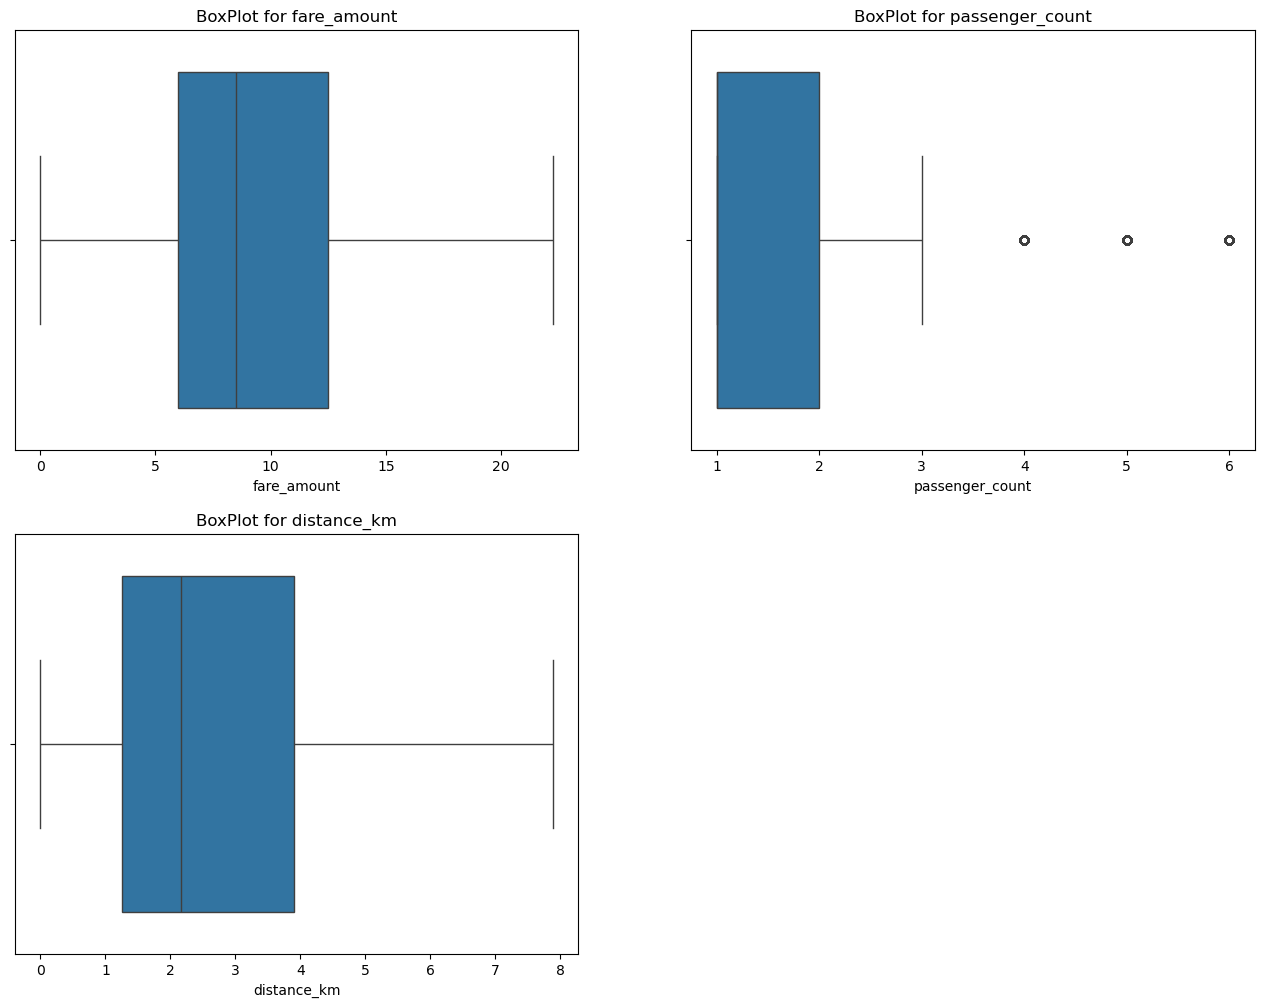

In [20]:
#EDA(Exploratory Data Analysis)
#Univariate Analysis for Numerical Data
#BoxPlot
plt.figure(figsize=(16,12))
for i in range(len(num_cols)):
    plt.subplot(2,2,i+1)
    sns.boxplot(x=df[num_cols[i]])
    plt.title(f'BoxPlot for {num_cols[i]}')
plt.show()

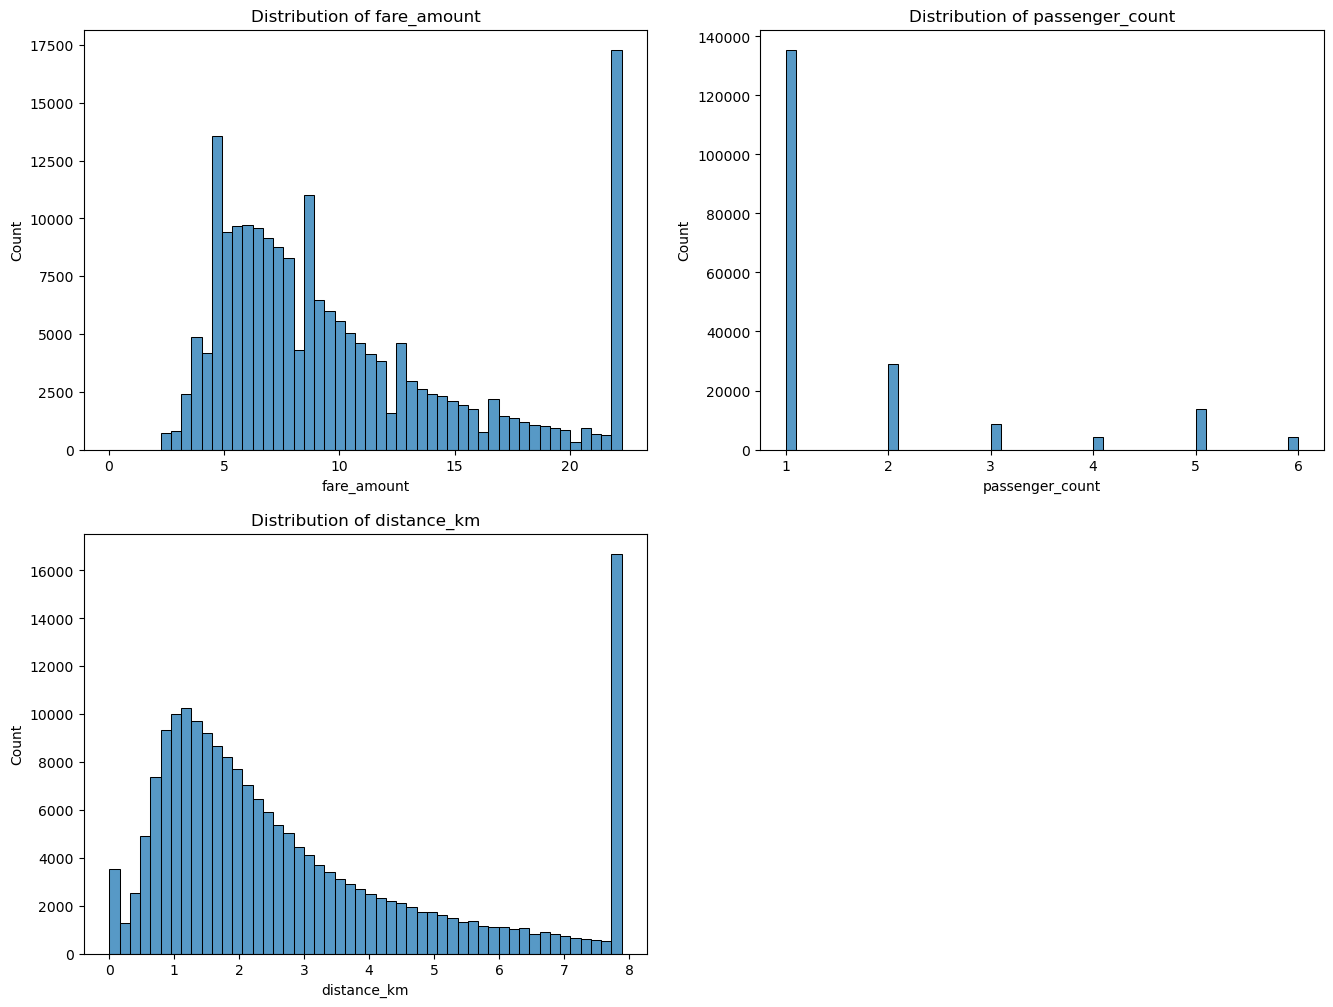

In [21]:
#HistPlot(To understand the Shape)
plt.figure(figsize=(16,12))
for i in range(len(num_cols)):
    plt.subplot(2,2,i+1)
    sns.histplot(x=df[num_cols[i]],bins=50)
    plt.title(f'Distribution of {num_cols[i]}')
plt.show()

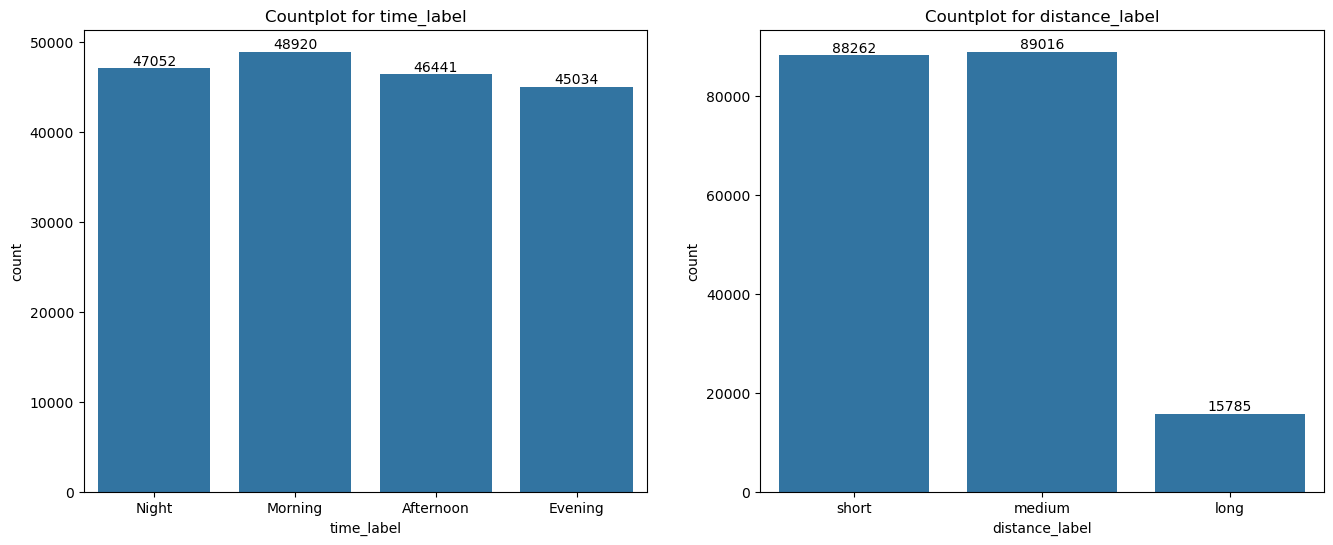

In [22]:
#Univariate Analysis for Categorical Data
#CountPlot
plt.figure(figsize=(16,6))
cat_cols=['time_label','distance_label']
for i in range(len(cat_cols)):
    plt.subplot(1,2,i+1)
    ax=sns.countplot(x=df[cat_cols[i]])
    ax.bar_label(ax.containers[0])
    plt.title(f'Countplot for {cat_cols[i]}')
plt.show()

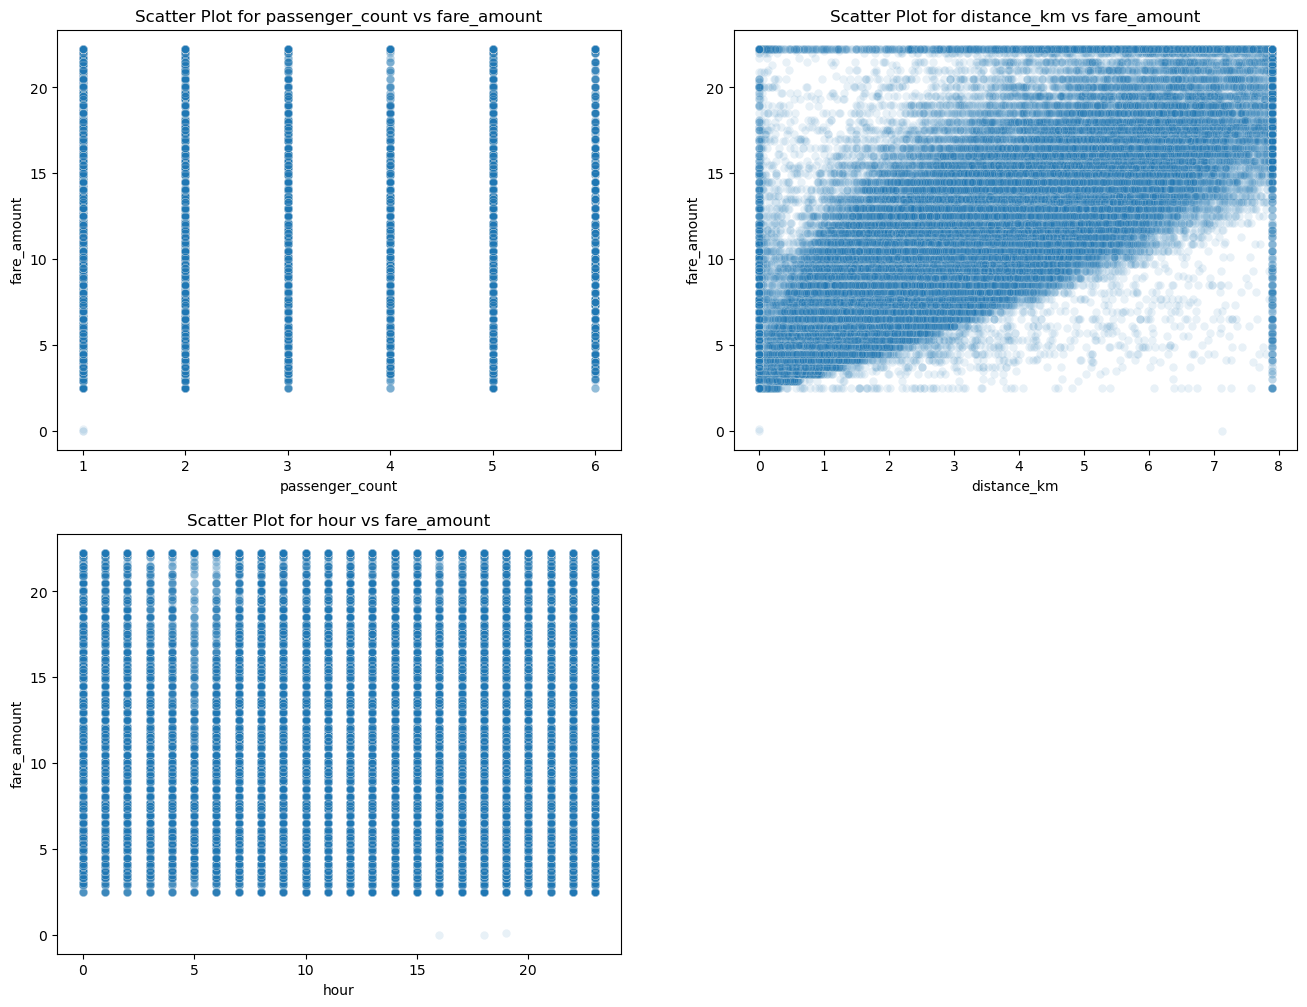

In [23]:
#Bivariate Analysis for Numerical to Numerical Data
#Scatter Plot
plt.figure(figsize=(16,12))
bi_num_cols=['passenger_count','distance_km','hour']
for i in range(len(bi_num_cols)):
    plt.subplot(2,2,i+1)
    sns.scatterplot(x=df[bi_num_cols[i]],y=df['fare_amount'],alpha=0.1)
    plt.title(f'Scatter Plot for {bi_num_cols[i]} vs fare_amount')
plt.show()

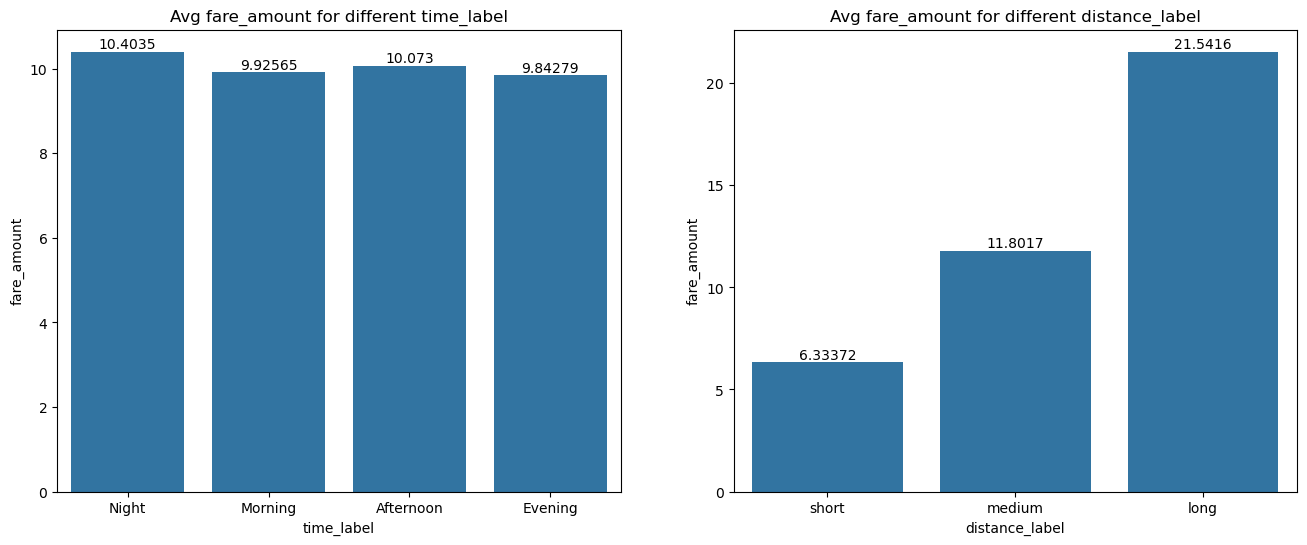

In [24]:
#Bivariate Analysis for Categorical to Numerical Data
#BarPlot
plt.figure(figsize=(16,6))
for i in range(len(cat_cols)):
    plt.subplot(1,2,i+1)
    ax=sns.barplot(x=df[cat_cols[i]],y=df['fare_amount'],errorbar=('ci',0))
    ax.bar_label(ax.containers[0])
    plt.title(f'Avg fare_amount for different {cat_cols[i]}')
plt.show()

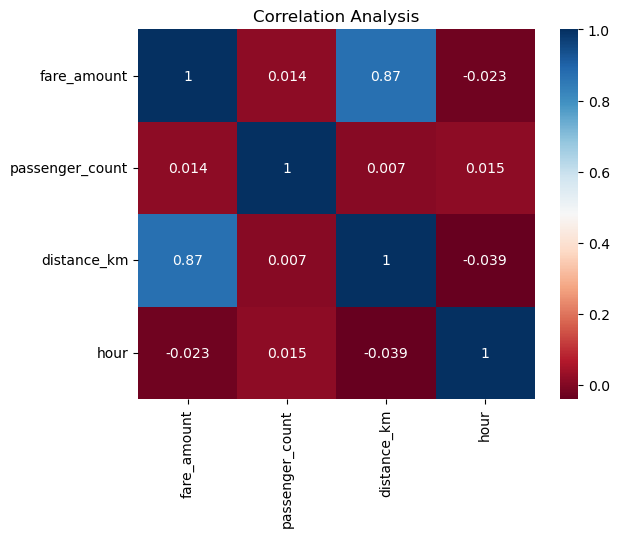

In [25]:
#Correlation Analysis
#Heatmap(To inderstamd the Correlations)
corr_cols=['fare_amount','passenger_count','distance_km','hour']
corr=df[corr_cols].corr()
sns.heatmap(corr,annot=True,cmap='RdBu')
plt.title(f'Correlation Analysis')
plt.show()

In [26]:
df.dtypes

Unnamed: 0                         int64
key                               object
fare_amount                      float64
pickup_datetime      datetime64[ns, UTC]
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
passenger_count                    int64
distance_km                      float64
hour                               int32
time_label                      category
distance_label                  category
dtype: object

In [27]:
#Encoding
df_dummies=pd.get_dummies(df,columns=['distance_label','time_label'],dtype=int,drop_first=True)
print(df_dummies.columns)
print(df_dummies.dtypes)

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'distance_km', 'hour',
       'distance_label_medium', 'distance_label_long', 'time_label_Morning',
       'time_label_Afternoon', 'time_label_Evening'],
      dtype='object')
Unnamed: 0                             int64
key                                   object
fare_amount                          float64
pickup_datetime          datetime64[ns, UTC]
pickup_longitude                     float64
pickup_latitude                      float64
dropoff_longitude                    float64
dropoff_latitude                     float64
passenger_count                        int64
distance_km                          float64
hour                                   int32
distance_label_medium                  int64
distance_label_long                    int64
time_label_Morning                     int64
time_label_Afternoo

In [28]:
x=df_dummies[['passenger_count','distance_km','hour','distance_label_medium','distance_label_long', 'time_label_Morning',
              'time_label_Afternoon', 'time_label_Evening']]
y=df_dummies['fare_amount']
print(x.shape)
print(y.shape)

(195100, 8)
(195100,)


In [29]:
#Splt the dataset into Training and Testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=57)
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

(156080, 8) (156080,)
(39020, 8) (39020,)


In [30]:
#Data Scaling/Normalization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaler=scaler.fit_transform(x_train)
x_test_scaler=scaler.transform(x_test)

x_train_scaler_df=pd.DataFrame(x_train_scaler,columns=x_train.columns)
x_train_scaler_df.head()

,passenger_count,distance_km,hour,distance_label_medium,distance_label_long,time_label_Morning,time_label_Afternoon,time_label_Evening
0,-0.529165,-0.193530,-0.534941,1.092301,-0.297489,1.729362,-0.558742,-0.548074
1,-0.529165,-0.133686,0.538898,1.092301,-0.297489,-0.578248,-0.558742,1.824572
2,-0.529165,-0.720766,-0.841751,-0.915499,-0.297489,1.729362,-0.558742,-0.548074
3,-0.529165,-0.863314,0.538898,-0.915499,-0.297489,-0.578248,-0.558742,1.824572
4,-0.529165,-1.236997,-0.381535,-0.915499,-0.297489,1.729362,-0.558742,-0.548074


In [31]:
#Training the Linear Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *

lr=LinearRegression()
lr.fit(x_train_scaler,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
#Evaluating the Model
def eval_model(ytest,ypred):
    mae = mean_absolute_error(ytest,ypred)
    mse = mean_squared_error(ytest,ypred)
    rmse = np.sqrt(mse)                              
    r2 = r2_score(ytest,ypred)               
    print('MAE',mae,'MSE',mse,'RMSE',rmse)
    print('R2',r2)

ypred_lr=lr.predict(x_test_scaler)
eval_model(y_test,ypred_lr)

MAE 1.7424150924803636 MSE 6.782786373425171 RMSE 2.604378308430857
R2 0.7683917763941344


In [33]:
#Generate Train and Test Scores
print('Train Score :',lr.score(x_train_scaler,y_train))
print('Test Score :',lr.score(x_test_scaler,y_test))

Train Score : 0.7659238805955774
Test Score : 0.7683917763941344


In [34]:
#Genrate Coefficients and Intercepts
coef=lr.coef_
Intercept=lr.intercept_
print('COEF',coef)
print('INTERCEPT',Intercept)

COEF [0.04502238 4.30060601 0.06969477 0.21842598 0.58206262 0.21982591
 0.33825263 0.16680693]
INTERCEPT 10.088940415171708


In [35]:
#Training with Random_Forest_Regressor
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x_train_scaler,y_train)

ypred_rf=rf.predict(x_test_scaler)
eval_model(y_test,ypred_rf)

MAE 1.8917801077130008 MSE 7.66831647540686 RMSE 2.769172525395783
R2 0.7381540477413403


In [36]:
#Generate Train and Test Scores
print('Train Score :',rf.score(x_train_scaler,y_train))
print('Test Score :',rf.score(x_test_scaler,y_test))

Train Score : 0.9428772653104869
Test Score : 0.7381540477413403


## Compare Linear Regression and Random Forest Regression

1. The Train and Test Scores for Linear Regression Model were consistent but overfitted for Random Forest Model.
2. But I still have to apply hyperparameter tuning to Random Forest Regression to finalise and get the most efficient model.
3. We dont normally tune a linear regression model since there wont be much of a change in the output.


In [37]:
#Tuning Random_Forest_Regression Model
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV

hparams={'n_estimators':[100,150,200],
         'max_depth':[6,8,10,12,13,14,15],
         'min_samples_leaf':[2,3,4,5,7,10,13,17]}

rs_rf=RandomizedSearchCV(RandomForestRegressor(random_state=42),param_distributions=hparams,cv=3,scoring='r2',n_jobs=-1,random_state=42)
rs_rf.fit(x_train_scaler,y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [6, 8, ...], 'min_samples_leaf': [2, 3, ...], 'n_estimators': [100, 150, ...]}"
,n_iter,10
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [38]:
#Find best params and best score
print('Best params :',rs_rf.best_params_)
print('Best score :',rs_rf.best_score_)

Best params : {'n_estimators': 200, 'min_samples_leaf': 3, 'max_depth': 8}
Best score : 0.7838395974014833


In [39]:
#Use the best_params to train the model
tuned_rf=rs_rf.best_estimator_

In [40]:
#Evaluate the Tuned Model
ypred_tuned_rf=tuned_rf.predict(x_test_scaler)
eval_model(y_test,ypred_tuned_rf)

MAE 1.6933725859842133 MSE 6.2939864474538245 RMSE 2.5087818652592784
R2 0.7850825692807359


In [41]:
#Generate Train and Test Scores
print('Train Score :',tuned_rf.score(x_train_scaler,y_train))
print('Test Score :',tuned_rf.score(x_test_scaler,y_test))

Train Score : 0.7887469052830073
Test Score : 0.7850825692807359


## Compare All Models

Since there is no overfitting and R2 of Tuned Random_Forest_Regressor is higher than Linear_Regression model,
I conclude Random_Forest is currently the best model.


In [42]:
#Evaluate Model Perfomance for Insights
print('-------Model Performance-------')
print("MAE :",mean_absolute_error(y_test,ypred_tuned_rf))
print("MSE :",mean_squared_error(y_test,ypred_tuned_rf))
print("RMSE:",np.sqrt(mean_squared_error(y_test,ypred_tuned_rf)))
print("R²  :",r2_score(y_test,ypred_tuned_rf))

print('\n-------Overfitting/Underfitting Check-------')
ytrain_pred_tuned_rf = tuned_rf.predict(x_train_scaler)
diff = r2_score(y_train,ytrain_pred_tuned_rf) - r2_score(y_test,ypred_tuned_rf)
print('Difference between Train and Test Predictions :',diff)      #The gap is very low.Hence the model is not overfitting/underfitting.

-------Model Performance-------
MAE : 1.6933725859842133
MSE : 6.2939864474538245
RMSE: 2.5087818652592784
R²  : 0.7850825692807359

-------Overfitting/Underfitting Check-------
Difference between Train and Test Predictions : 0.00366433600227134


In [43]:
#Interpret Feature Importance
feat_imp=pd.DataFrame({'Features':x.columns,'Importance':tuned_rf.feature_importances_}).sort_values('Importance',ascending=False)
feat_imp.head(10)

,Features,Importance
1,distance_km,0.983525
2,hour,0.008993
3,distance_label_medium,0.003871
4,distance_label_long,0.002266
0,passenger_count,0.000788
6,time_label_Afternoon,0.000326
5,time_label_Morning,0.000188
7,time_label_Evening,0.000044


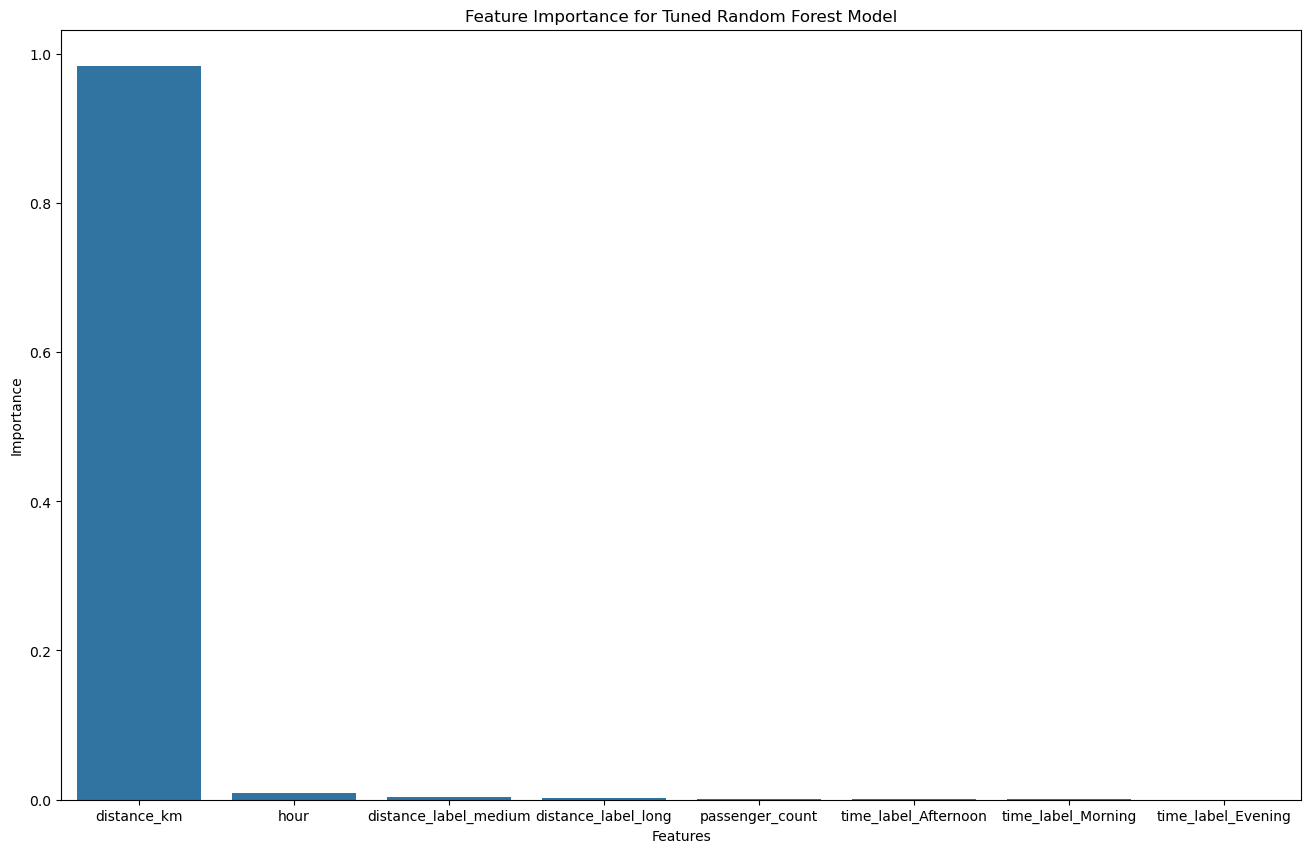

In [44]:
#Feature Importance Visualization(for better understanding)
plt.figure(figsize=(16,10))
sns.barplot(data=feat_imp,x='Features',y='Importance')
plt.title(f'Feature Importance for Tuned Random Forest Model')
plt.show()

## Business Interpretation of Important Features

As you can see from the barplot,Distance is the most important feature for predicting fare prices.It alone accounts
for a vast majority of this model's predictive power.Whereas other features like time_of_day,passenger_count and distance_category
contribute very low.This suggests that the underlying pricing structure behaves like a simple metred fare (distance x price) rather 
than a demand based or time based pricing.For a company,this means:
1. The model is good at figuring out fares based on distance.
2. But it doesn't know about things like demand based or time based pricing because that information was never in the data


In [45]:
#Make predictions for New data(Sample data got from using claude)
new_data=pd.DataFrame({'passenger_count':[1,  4,  2,  6,  3], 
                            'distance_km':[1.5, 5.0, 15.0, 3.2, 8.5],
                            'hour':[9,  18, 23,  13,  1],
                            'distance_label_medium':[0,  1,  0,   1,   1],
                            'distance_label_long':[0,  0,  1,   0,   0],
                            'time_label_Morning':[1,  0,  0,   0,   0],
                            'time_label_Afternoon':[0,  0,  0,   1,   0],
                            'time_label_Evening':[0,  1,  0,   0,   0]})
new_data_scaled=scaler.transform(new_data)
new_data['predicted_fare_amount']=tuned_rf.predict(new_data_scaled)
new_data

,passenger_count,distance_km,hour,distance_label_medium,distance_label_long,time_label_Morning,time_label_Afternoon,time_label_Evening,predicted_fare_amount
0,1,1.5,9,0,0,1,0,0,7.321340
1,4,5.0,18,1,0,0,0,1,15.220462
2,2,15.0,23,0,1,0,0,0,21.507598
3,6,3.2,13,1,0,0,1,0,11.410419
4,3,8.5,1,1,0,0,0,0,18.571998


## Insights from the above predictions

From the above predictions we can confidently say that the model's predicting capabilities are good.And
the model also shows some non-linearity(i.e) The model doesn't charge for a fixed rate per km - the price per km 
changes a bit depending upon the ride.And that fits because a linear regression model could not capture these insights.


## Use Cases and Benefits
This model's fare prediction can have several practical use cases:

1. **Real-time fare estimation** : Before a rider even requests a ride, the app can show price prediction based
                              on pickup/dropoff points.

2. **Drivers earnings forecast** : Drivers can use fare predictions to estimate expected earnings from a given trip
                              and make informed decisions.

3. **Anomaly detection** : Once you know what a 'normal' predicted fare looks like for a certain distance, you 
                      can understand if someone is trying to charge more for that particular distance.

4. **Business and Revenue Forecasting** : If a company has a rough idea of the number of rides they can expect and some rough
                                      distances/times, they can use the model to predict fare for each ride and add up to
                                      get an estimate of the total revenue.

## Recommendations

**What works well** : The model reliably estimates fares based on distance, achieving 72% of predictions within $2 of
                  actual fare and reducing error by 61% compared to an average-fare baseline.

**Key Limitation** : Distance accounts for 94% of the predictive power, so the model cannot capture demand spikes,
                 surge pricing,weather or traffic as none of the info is in the dataset.Thus, this model
                 should not be used during demand spikes.

**Recommended Steps** :
1. Add real-time demand/supply data or signals to capture surge pricing.
2. Add weather and holiday features.
3. Validate on more recent data to check price drifting over-time.

**Deployment Guidance** : Suitable for baseline fare prediction with a disclaimer actual fares may
                        vary with real-time conditions.